In [1]:
"""fire_detection_model.h5
Module 0.1: Configuration Manager for CNN + SVM Fire Detection
Author: CNN-SVM Project
Description: Centralized configuration for all hyperparameters and paths.
"""

import torch
import os
import json
from pathlib import Path
from datetime import datetime

class Config:
    """
    Configuration Manager - Stores all system parameters
    """
    
    def __init__(self, dataset_root="Datasets/forest_fire"):
        
        # ============================================
        # HARDWARE CONFIGURATION
        # ============================================
        # The CNN feature extractor will run on GPU
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.num_workers = 0 # Keep at 0 for notebook safety
        
        print(f"🔥 Device configured: {self.device}")
        
        # ============================================
        # PATH CONFIGURATION
        # ============================================
        self.DATASET_ROOT = Path(dataset_root)
        self.Training_VAL_PATH = self.DATASET_ROOT / "Training and Validation"
        self.TEST_PATH = self.DATASET_ROOT / "Testing"
        
        # --- NEW Paths for this project ---
        # Directory to save pre-computed features
        self.FEATURE_DIR = Path("precomputed_features")
        # Directory for SVM model
        self.MODEL_DIR = Path("models")
        
        # Create directories
        self.FEATURE_DIR.mkdir(exist_ok=True, parents=True)
        self.MODEL_DIR.mkdir(exist_ok=True, parents=True)
        
        # Final file paths
        self.TRAIN_FEATURES_PATH = self.FEATURE_DIR / "train_features.pt"
        self.VAL_FEATURES_PATH = self.FEATURE_DIR / "val_features.pt"
        self.SVM_MODEL_PATH = self.MODEL_DIR / "svm_model.joblib"
        
        # ============================================
        # DATA SPLIT CONFIGURATION
        # ============================================
        # This is for the *initial* split of images
        self.VAL_SPLIT = 0.2
        self.RANDOM_SEED = 42
        
        # ============================================
        # CNN FEATURE EXTRACTOR CONFIGURATION
        # ============================================
        # We will use VGG16, as it's a classic and powerful extractor
        self.CNN_MODEL = "vgg16"
        # We'll grab the output of the *last* layer before the final classifier
        # For VGG16, this is 'avgpool', which gives a 512-dim vector
        self.FEATURE_LAYER = "avgpool"
        self.FEATURE_VECTOR_SIZE = 512 # 512 for VGG16 avgpool
        
        # ImageNet normalization (standard for pre-trained models)
        self.MEAN = [0.485, 0.456, 0.406]
        self.STD = [0.229, 0.224, 0.225]
        self.CNN_INPUT_SIZE = (224, 224) # VGG16 expects 224x224
        
        # ============================================
        # FEATURE GENERATION CONFIGURATION
        # ============================================
        # How many augmented versions per training image?
        self.AUGMENTATION_MULTIPLIER = 5
        self.AUGMENTATION_BATCH_SIZE = 32 # Batch size for GPU feature extraction
        
        # ============================================
        # SVM TRAINING CONFIGURATION
        # ============================================
        # 'rbf' (Radial Basis Function) is a good default kernel
        self.SVM_KERNEL = 'rbf'
        # 'C' is the regularization parameter
        self.SVM_C = 1.0 
        # Whether to run a full grid search (slow but better)
        self.SVM_GRID_SEARCH = True
        
        # ============================================
        # DETECTION (SLIDING WINDOW) CONFIGURATION
        # ============================================
        # Window size: 128x128 pixels
        self.WINDOW_SIZE = (128, 128) 
        # Step size: Move window 32 pixels at a time
        self.STEP_SIZE = 32
        # Don't save boxes with confidence < 70%
        self.DETECTION_THRESHOLD = 0.7 
        # Non-Maximum Suppression (NMS) threshold
        self.NMS_THRESHOLD = 0.3
        
        print("✅ CNN+SVM Configuration initialized successfully!")

    def validate_paths(self):
        """
        Validate that all required dataset paths exist
        """
        print("\n🔍 Validating dataset paths...")
        
        paths_to_check = [
            (self.DATASET_ROOT, "Dataset root"),
            (self.Training_VAL_PATH, "Training and Validation folder"),
            (self.Training_VAL_PATH / "fire", "Training fire folder"),
            (self.Training_VAL_PATH / "nofire", "Training nofire folder"),
            (self.TEST_PATH, "Testing folder"),
            (self.TEST_PATH / "fire", "Testing fire folder"),
            (self.TEST_PATH / "nofire", "Testing nofire folder"),
        ]
        
        all_valid = True
        for path, description in paths_to_check:
            if path.exists():
                print(f"   ✓ {description}: {path}")
            else:
                print(f"   ✗ {description}: {path} NOT FOUND!")
                all_valid = False
                
        return all_valid

    def print_summary(self):
        """
        Print a comprehensive summary of all configuration parameters
        """
        print("\n" + "="*60)
        print("🔥 CNN+SVM CONFIGURATION SUMMARY")
        print("="*60)
        
        print(f"\n📊 HARDWARE:")
        print(f"   Device: {self.device}")
        
        print(f"\n📁 DATASET & PATHS:")
        print(f"   Root: {self.DATASET_ROOT}")
        print(f"   Feature Dir: {self.FEATURE_DIR}")
        print(f"   SVM Model: {self.SVM_MODEL_PATH}")
        
        print(f"\n🧠 CNN FEATURE EXTRACTOR:")
        print(f"   Model: {self.CNN_MODEL}")
        print(f"   Layer: {self.FEATURE_LAYER}")
        print(f"   Input Size: {self.CNN_INPUT_SIZE}")
        print(f"   Vector Size: {self.FEATURE_VECTOR_SIZE}")
        
        print(f"\n📈 SVM TRAINING:")
        print(f"   Kernel: {self.SVM_KERNEL}")
        print(f"   Run Grid Search: {self.SVM_GRID_SEARCH}")
        
        print(f"\n🔍 SLIDING WINDOW:")
        print(f"   Window Size: {self.WINDOW_SIZE}")
        print(f"   Step Size: {self.STEP_SIZE}")
        print(f"   Detection Threshold: {self.DETECTION_THRESHOLD}")
        
        print("\n" + "="*60 + "\n")

# ============================================
# TESTING CODE
# ============================================
if __name__ == "__main__":
    print("🧪 Testing Module 0.1: Configuration Manager (CNN+SVM)\n")
    
    # IMPORTANT: Change this path to match YOUR dataset location
    config = Config(dataset_root="Datasets/forest_fire/")
    
    # Validate paths
    paths_valid = config.validate_paths()
    
    # Print summary
    config.print_summary()
    
    if paths_valid:
        print("✅ Module 0.1 test PASSED - Configuration is ready!")
    else:
        print("⚠️  WARNING: Some dataset paths are invalid!")

🧪 Testing Module 0.1: Configuration Manager (CNN+SVM)

🔥 Device configured: cuda
✅ CNN+SVM Configuration initialized successfully!

🔍 Validating dataset paths...
   ✓ Dataset root: Datasets\forest_fire
   ✓ Training and Validation folder: Datasets\forest_fire\Training and Validation
   ✓ Training fire folder: Datasets\forest_fire\Training and Validation\fire
   ✓ Training nofire folder: Datasets\forest_fire\Training and Validation\nofire
   ✓ Testing folder: Datasets\forest_fire\Testing
   ✓ Testing fire folder: Datasets\forest_fire\Testing\fire
   ✓ Testing nofire folder: Datasets\forest_fire\Testing\nofire

🔥 CNN+SVM CONFIGURATION SUMMARY

📊 HARDWARE:
   Device: cuda

📁 DATASET & PATHS:
   Root: Datasets\forest_fire
   Feature Dir: precomputed_features
   SVM Model: models\svm_model.joblib

🧠 CNN FEATURE EXTRACTOR:
   Model: vgg16
   Layer: avgpool
   Input Size: (224, 224)
   Vector Size: 512

📈 SVM TRAINING:
   Kernel: rbf
   Run Grid Search: True

🔍 SLIDING WINDOW:
   Window Size:

In [2]:
"""
Module 1.1: CNN Feature Extractor (CNN+SVM)
Author: CNN-SVM Project
Description: Loads a pre-trained CNN (VGG16) and sets it up to
             extract high-level feature vectors from image patches.
"""

# This script assumes 'Config' class (Module 0.1) is in memory.

import torch
import torch.nn as nn
import torchvision.models as models
import albumentations as A
from albumentations.pytorch import ToTensorV2
from PIL import Image
import numpy as np

# --- 1. Image Preprocessing ---

def get_image_transform(config):
    """
    Returns the specific preprocessing transform (resize, normalize, to-tensor)
    that the pre-trained CNN expects.
    """
    return A.Compose([
        A.Resize(config.CNN_INPUT_SIZE[0], config.CNN_INPUT_SIZE[1]),
        A.Normalize(mean=config.MEAN, std=config.STD),
        ToTensorV2()
    ])

# --- 2. The Feature Extractor Class ---

class FeatureExtractor:
    """
    A wrapper class for the pre-trained CNN model.
    It handles loading the model and registering the "hook"
    to capture the feature vector from an intermediate layer.
    """
    def __init__(self, config):
        self.config = config
        self.device = config.device
        
        # 1. Load the pre-trained model
        self.model = self.load_model()
        self.model.eval() # Set to evaluation mode
        self.model.to(self.device)
        
        # 2. Storage for the captured features
        self.features = None
        
        # 3. Register the hook
        self.register_hook()
        print(f"✅ FeatureExtractor ready. Hook registered on final layer.")

    def load_model(self):
        """
        Loads the VGG16 'features' module and appends a 
        Global Average Pooling layer. We are *discarding*
        the original VGG 'classifier' entirely.
        """
        if self.config.CNN_MODEL == "vgg16":
            # 1. Load the pre-trained VGG-16 model
            vgg16 = models.vgg16(weights=models.VGG16_Weights.DEFAULT)
            
            # 2. Get *only* the 'features' part
            # This part ends with a (B, 512, 7, 7) output
            vgg_features = vgg16.features
            
            # 3. Create our new model
            # We add our own pooling layer to get the 512-dim vector
            model = nn.Sequential(
                vgg_features,
                nn.AdaptiveAvgPool2d((1, 1)) # Outputs (B, 512, 1, 1)
            )
            return model
        else:
            raise ValueError(f"Model {self.config.CNN_MODEL} not supported.")

    def _hook_fn(self, module, input, output):
        """The hook function that runs on the forward pass."""
        # The output of our new model is (B, 512, 1, 1).
        # We flatten it to (B, 512) to get a clean vector.
        self.features = torch.flatten(output, 1)

    def register_hook(self):
        """
        Attaches the hook to the *last layer* of our new
        nn.Sequential model (which is the AdaptiveAvgPool2d).
        """
        # The last module in our nn.Sequential
        target_layer = self.model[-1]
        target_layer.register_forward_hook(self._hook_fn)

    def extract_features(self, image_batch_tensor):
        """
        The main function. Passes a batch of images through the model
        and returns the captured feature vectors.
        """
        # We only need to run the model, the hook does the rest
        with torch.no_grad():
            _ = self.model(image_batch_tensor.to(self.device))
        
        # Return the features captured by the hook
        return self.features.cpu().numpy()

# ============================================
# TESTING CODE (Module 1.1)
# ============================================
# This will run when you execute the cell

print("\n🧪 Testing Module 1.1: CNN Feature Extractor\n")

try:
    # 1. Check for dependencies
    if 'config' not in locals():
        print("ERROR: 'config' not found. Please run Module 0.1 first.")
        raise NameError("config")
    
    # 2. Initialize the extractor
    extractor = FeatureExtractor(config)
    
    # 3. Load a sample test image
    test_img_path = next((config.TEST_PATH / "fire").glob("*.jpg"))
    print(f"   Loading sample image: {test_img_path}")
    image = np.array(Image.open(test_img_path).convert('RGB'))
    
    # 4. Preprocess the image
    transform = get_image_transform(config)
    image_tensor = transform(image=image)['image']
    
    # Add a batch dimension: (C, H, W) -> (1, C, H, W)
    image_batch = image_tensor.unsqueeze(0)
    print(f"   Image tensor shape: {image_batch.shape}")
    
    # 5. Extract features
    features = extractor.extract_features(image_batch)
    
    print("\n✅ Feature extraction successful.")
    print(f"   Feature vector shape: {features.shape}")
    
    # --- Stricter Test ---
    if features.shape[1] == config.FEATURE_VECTOR_SIZE:
        print(f"   ✅ Vector size matches configuration ({config.FEATURE_VECTOR_SIZE}).")
        print("\n✅ Module 1.1 test PASSED!")
    else:
        print(f"   ❌ ERROR: Vector size {features.shape[1]} does not match config {config.FEATURE_VECTOR_SIZE}.")
        print("\n❌ Module 1.1 test FAILED!")

except Exception as e:
    print(f"\n❌ Module 1.1 test FAILED: {e}")
    import traceback
    traceback.print_exc()


🧪 Testing Module 1.1: CNN Feature Extractor

✅ FeatureExtractor ready. Hook registered on final layer.
   Loading sample image: Datasets\forest_fire\Testing\fire\abc169.jpg
   Image tensor shape: torch.Size([1, 3, 224, 224])

✅ Feature extraction successful.
   Feature vector shape: (1, 512)
   ✅ Vector size matches configuration (512).

✅ Module 1.1 test PASSED!


In [3]:
"""
Module 1.2: Feature Dataset Generator (CNN+SVM)
Author: CNN-SVM Project
Description: A one-time script to run all images through the CNN,
             extract their feature vectors, and save them to disk
             for the SVM to train on.
"""

# This script assumes 'Config' (Cell 1) and 'FeatureExtractor' (Cell 2)
# and 'get_image_transform' (Cell 2) are in memory.

import torch
import numpy as np
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from PIL import Image
from tqdm.notebook import tqdm
import os

# --- 1. Dataset for Image Loading ---

class ImageDataset(Dataset):
    """A simple dataset to load image paths for extraction."""
    def __init__(self, image_paths, labels, transform):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform
        
    def __len__(self):
        return len(self.image_paths)
        
    def __getitem__(self, idx):
        try:
            image = np.array(Image.open(self.image_paths[idx]).convert('RGB'))
            image = self.transform(image=image)['image']
            label = self.labels[idx]
            return image, label
        except Exception as e:
            print(f"Warning: Error loading {self.image_paths[idx]}. Skipping. Error: {e}")
            return torch.zeros((3, 224, 224)), -1 # Return dummy data

# --- 2. Augmentation Pipeline ---

def get_augmentation_pipeline(config):
    """
    Defines the augmentations (flip, rotate, etc.)
    and the final CNN preprocessing.
    """
    return A.Compose([
        # Augmentations
        A.HorizontalFlip(p=0.5),
        A.Rotate(limit=30, p=0.5),
        A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, p=0.5),
        
        # Preprocessing (from Module 1.1)
        A.Resize(config.CNN_INPUT_SIZE[0], config.CNN_INPUT_SIZE[1]),
        A.Normalize(mean=config.MEAN, std=config.STD),
        ToTensorV2()
    ])

# --- 3. The Generation Function ---

def generate_features(extractor, image_paths, labels, config, augment=False):
    """
    Runs all specified images through the feature extractor
    and returns a big list of features and labels.
    """
    if augment:
        transform = get_augmentation_pipeline(config)
        num_versions = config.AUGMENTATION_MULTIPLIER
        desc = "Extracting Augmented Features"
    else:
        # Simple transform (no aug) for validation
        transform = get_image_transform(config) 
        num_versions = 1
        desc = "Extracting Validation Features"
        
    dataset = ImageDataset(image_paths, labels, transform)
    
    # We will re-use the same loader
    loader = DataLoader(
        dataset,
        batch_size=config.AUGMENTATION_BATCH_SIZE,
        shuffle=False, # We shuffle later
        num_workers=config.num_workers
    )
    
    all_features = []
    all_labels = []
    
    for _ in range(num_versions): # Loop N times for augmentations
        pbar = tqdm(loader, desc=f"{desc} (Pass {_+1}/{num_versions})")
        for images, labels in pbar:
            # Skip bad images
            valid_idx = (labels != -1)
            if not valid_idx.any():
                continue
                
            images = images[valid_idx]
            labels = labels[valid_idx]

            # Extract features using the CNN
            features = extractor.extract_features(images)
            
            all_features.append(features)
            all_labels.append(labels.numpy())
            
    # Concatenate all lists into giant numpy arrays
    all_features = np.concatenate(all_features, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)
    
    return all_features, all_labels

# ============================================
# EXECUTION & TESTING (Module 1.2)
# ============================================
# This will run when you execute the cell

print("\n🧪 Running Module 1.2: Feature Dataset Generator\n")

try:
    # 1. Check for dependencies
    if 'config' not in locals(): raise NameError("config")
    if 'extractor' not in locals():
        print("   Initializing FeatureExtractor (from Cell 2)...")
        extractor = FeatureExtractor(config)
    
    print("   Loading image paths from dataset...")
    
    # 2. Load all image paths
    fire_paths = list((config.Training_VAL_PATH / "fire").glob("*.jpg"))
    nofire_paths = list((config.Training_VAL_PATH / "nofire").glob("*.jpg"))
    
    all_paths = [str(p) for p in (fire_paths + nofire_paths)]
    all_labels = [1] * len(fire_paths) + [0] * len(nofire_paths)
    
    print(f"   Found {len(fire_paths)} fire images and {len(nofire_paths)} no-fire images.")
    
    # 3. Split into Train and Validation sets
    train_paths, val_paths, train_labels, val_labels = train_test_split(
        all_paths, 
        all_labels, 
        test_size=config.VAL_SPLIT, 
        random_state=config.RANDOM_SEED,
        stratify=all_labels # Keep class balance
    )
    
    print(f"   Splitting into {len(train_paths)} train and {len(val_paths)} val images.")
    
    # --- 4. THIS IS THE HEAVY TASK ---
    
    # Generate and save Training features
    print("\nStarting Training feature generation... (This will take a while)")
    train_features, train_labels_np = generate_features(
        extractor, 
        train_paths, 
        train_labels, 
        config, 
        augment=True
    )
    
    # Save training features
    print(f"\n   Saving {train_features.shape[0]} training features...")
    torch.save(
        {'features': train_features, 'labels': train_labels_np}, 
        config.TRAIN_FEATURES_PATH
    )
    print(f"   ✅ Saved to {config.TRAIN_FEATURES_PATH}")

    # Generate and save Validation features
    print("\nStarting Validation feature generation...")
    val_features, val_labels_np = generate_features(
        extractor, 
        val_paths, 
        val_labels, 
        config, 
        augment=False # No augmentations for validation
    )
    
    # Save validation features
    print(f"\n   Saving {val_features.shape[0]} validation features...")
    torch.save(
        {'features': val_features, 'labels': val_labels_np}, 
        config.VAL_FEATURES_PATH
    )
    print(f"   ✅ Saved to {config.VAL_FEATURES_PATH}")
    
    print("\n✅ Module 1.2 feature generation complete!")
    print("\n   --- Summary ---")
    print(f"   Training features shape:   {train_features.shape}")
    print(f"   Training labels shape:   {train_labels_np.shape}")
    print(f"   Validation features shape: {val_features.shape}")
    print(f"   Validation labels shape: {val_labels_np.shape}")
    print(features.shape)
    
except Exception as e:
    print(f"\n❌ Module 1.2 feature generation FAILED: {e}")
    import traceback
    traceback.print_exc()


🧪 Running Module 1.2: Feature Dataset Generator

   Loading image paths from dataset...
   Found 928 fire images and 904 no-fire images.
   Splitting into 1465 train and 367 val images.

Starting Training feature generation... (This will take a while)


Extracting Augmented Features (Pass 1/5):   0%|          | 0/46 [00:00<?, ?it/s]

Extracting Augmented Features (Pass 2/5):   0%|          | 0/46 [00:00<?, ?it/s]

Extracting Augmented Features (Pass 3/5):   0%|          | 0/46 [00:00<?, ?it/s]

Extracting Augmented Features (Pass 4/5):   0%|          | 0/46 [00:00<?, ?it/s]

Extracting Augmented Features (Pass 5/5):   0%|          | 0/46 [00:00<?, ?it/s]


   Saving 7325 training features...
   ✅ Saved to precomputed_features\train_features.pt

Starting Validation feature generation...


Extracting Validation Features (Pass 1/1):   0%|          | 0/12 [00:00<?, ?it/s]


   Saving 367 validation features...
   ✅ Saved to precomputed_features\val_features.pt

✅ Module 1.2 feature generation complete!

   --- Summary ---
   Training features shape:   (7325, 512)
   Training labels shape:   (7325,)
   Validation features shape: (367, 512)
   Validation labels shape: (367,)
(1, 512)


In [4]:
pip install scikit-learn joblib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


C:\Users\Sreeh\AppData\Local\Temp\ipykernel_21640\193814459.py:47: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  train_data = torch.load(config.TRAIN_FEATURES_PATH)



🧪 Running Module 1.3: SVM Training Pipeline

Loading pre-computed features...


C:\Users\Sreeh\AppData\Local\Temp\ipykernel_21640\193814459.py:48: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  val_data = torch.load(config.VAL_FEATURES_PATH)


Normalizing features...
   Scaler saved to models\svm_scaler.joblib

Starting SVM Grid Search... (This can be slow)
Fitting 1 folds for each of 6 candidates, totalling 6 fits

Best parameters found: {'C': 0.1, 'kernel': 'rbf'}


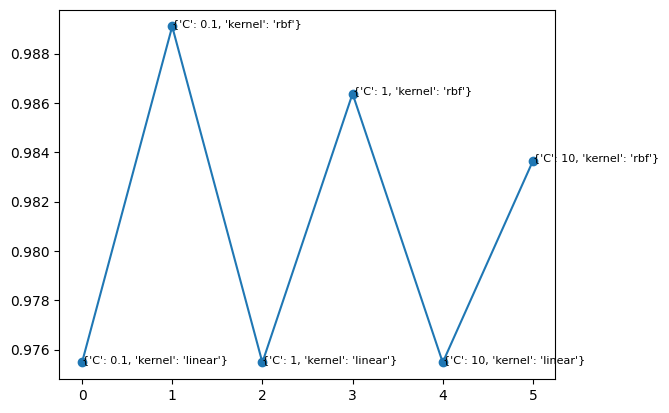

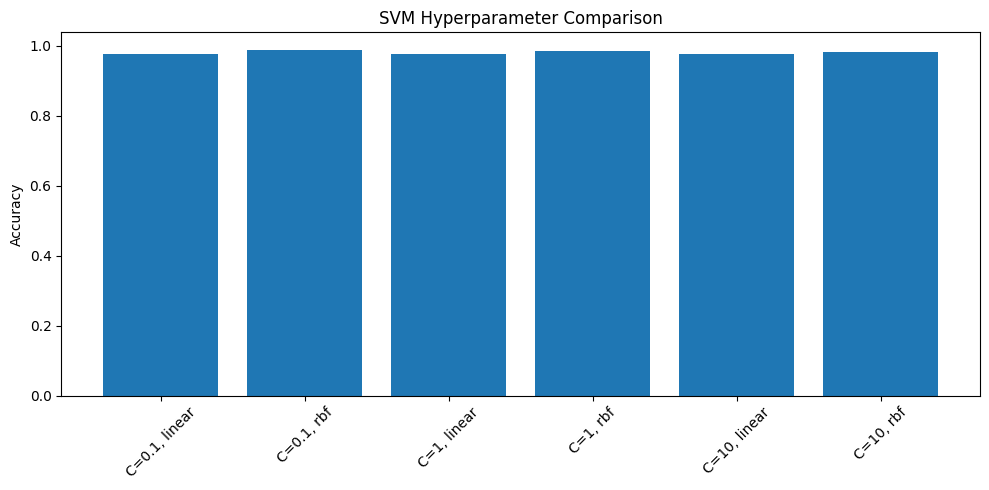


--- Validation Set Performance ---
              precision    recall  f1-score   support

  NoFire (0)       0.99      0.99      0.99       181
    Fire (1)       0.99      0.99      0.99       186

    accuracy                           0.99       367
   macro avg       0.99      0.99      0.99       367
weighted avg       0.99      0.99      0.99       367


✅ SVM model trained and saved to models\svm_model.joblib

✅ Module 1.3 training complete!


In [5]:
"""
Module 1.3: SVM Training Pipeline (CNN+SVM)
Author: CNN-SVM Project
Description: Loads the pre-computed features, trains, evaluates,
             and saves the SVM classifier.
"""

# This script assumes 'Config' (Cell 1) is in memory.

import torch
import numpy as np
import joblib
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, PredefinedSplit
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset, DataLoader

# --- 1. Module 0.2: Data Loader (for features) ---
# We define this here as it's only used for training
class FeatureDataset(Dataset):
    """A dataset for loading pre-computed features and labels."""
    def __init__(self, features_path):
        data = torch.load(features_path)
        # We normalize the features for the SVM
        self.scaler = StandardScaler().fit(data['features'])
        self.features = self.scaler.transform(data['features'])
        self.labels = data['labels']
        print(f"Loaded {len(self.features)} samples from {features_path}")
        
    def __len__(self):
        return len(self.features)
        
    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

# --- 2. The Training Function ---

def train_svm(config):
    """
    Loads data, trains the SVM, and saves the best model.
    """
    
    # 1. Load data
    print("Loading pre-computed features...")
    # We load both train and val and combine them for GridSearchCV
    train_data = torch.load(config.TRAIN_FEATURES_PATH)
    val_data = torch.load(config.VAL_FEATURES_PATH)
    
    X_train = train_data['features']
    y_train = train_data['labels']
    X_val = val_data['features']
    y_val = val_data['labels']
    
    # Combine for grid search
    X_full = np.concatenate((X_train, X_val), axis=0)
    y_full = np.concatenate((y_train, y_val), axis=0)
    
    # --- 2. Normalize Features (Crucial for SVM) ---
    print("Normalizing features...")
    scaler = StandardScaler()
    X_full_scaled = scaler.fit_transform(X_full)
    
    # We must save this scaler to use it during detection!
    scaler_path = config.MODEL_DIR / "svm_scaler.joblib"
    joblib.dump(scaler, scaler_path)
    print(f"   Scaler saved to {scaler_path}")
    
    # 3. Train the SVM
    if config.SVM_GRID_SEARCH:
        print("\nStarting SVM Grid Search... (This can be slow)")
        
        # Define the parameter grid
        param_grid = {
            'C': [0.1, 1, 10],
            'kernel': ['linear', 'rbf']
        }
        
        # Create a "PredefinedSplit" to tell GridSearchCV
        # exactly which samples are train (0) and which are test (-1)
        test_fold = [-1] * len(X_train) + [0] * len(X_val)
        ps = PredefinedSplit(test_fold=test_fold)
        
        # Initialize GridSearchCV
        svm = SVC(probability=True) # probability=True is needed for confidence scores
        grid_search = GridSearchCV(
            svm, param_grid, cv=ps, n_jobs=-1, verbose=2
        )
        
        # Run the search
        grid_search.fit(X_full_scaled, y_full)
        
        print(f"\nBest parameters found: {grid_search.best_params_}")
        best_svm = grid_search.best_estimator_

                # 📊 Plot Grid Search Performance
        results = grid_search.cv_results_
        mean_scores = results['mean_test_score']
        params = results['params']
        
        import matplotlib.pyplot as plt

        plt.plot(range(len(mean_scores)), mean_scores, marker='o')
        
        for i, param in enumerate(params):
            plt.text(i, mean_scores[i], str(param), fontsize=8)
        
        labels = [f"C={p['C']}, {p['kernel']}" for p in params]

        plt.figure(figsize=(10,5))
        plt.bar(labels, mean_scores)
        plt.xticks(rotation=45)
        plt.ylabel("Accuracy")
        plt.title("SVM Hyperparameter Comparison")
        plt.tight_layout()
        plt.show()
            
    else:
        print("\nTraining a single SVM with default config...")
        best_svm = SVC(
            kernel=config.SVM_KERNEL,
            C=config.SVM_C,
            probability=True
        )
        # We still scale the training data for the single fit
        X_train_scaled = scaler.transform(X_train)
        best_svm.fit(X_train_scaled, y_train)

    # 4. Final Evaluation on Validation Set
    print("\n--- Validation Set Performance ---")
    X_val_scaled = scaler.transform(X_val)
    y_pred = best_svm.predict(X_val_scaled)
    
    print(classification_report(y_val, y_pred, target_names=["NoFire (0)", "Fire (1)"]))
    
    # 5. Save the final, trained model
    joblib.dump(best_svm, config.SVM_MODEL_PATH)
    print(f"\n✅ SVM model trained and saved to {config.SVM_MODEL_PATH}")
    
    return best_svm

# ============================================
# EXECUTION & TESTING (Module 1.3)
# ============================================
# This will run when you execute the cell

print("\n🧪 Running Module 1.3: SVM Training Pipeline\n")

try:
    # 1. Check for dependencies
    if 'config' not in locals():
        print("ERROR: 'config' not found. Please run Module 0.1 first.")
        raise NameError("config")
    
    # 2. Check if feature files exist
    if not config.TRAIN_FEATURES_PATH.exists() or not config.VAL_FEATURES_PATH.exists():
        print(f"ERROR: Feature files not found.")
        print(f"   Missing: {config.TRAIN_FEATURES_PATH}")
        print(f"   Missing: {config.VAL_FEATURES_PATH}")
        print("   Please run Module 1.2 (Feature Generator) first.")
        raise FileNotFoundError("Feature files missing")

    # 3. Start training
    # This is the main event for this cell
    trained_svm = train_svm(config)
    
    print("\n✅ Module 1.3 training complete!")

except Exception as e:
    print(f"\n❌ Module 1.3 training FAILED: {e}")
    import traceback
    traceback.print_exc()


🧪 Testing Module 2.1: Sliding Window Detector

Loading models for detection...
✅ FeatureExtractor ready. Hook registered on final layer.
✅ All detection models loaded successfully.

   Running detection on: Datasets\forest_fire\Testing\fire\abc169.jpg


Detecting:   0%|          | 0/9 [00:00<?, ?it/s]


✅ Detection complete.
   Found 14 raw (overlapping) boxes.
   Visualizing raw detections (before NMS)...


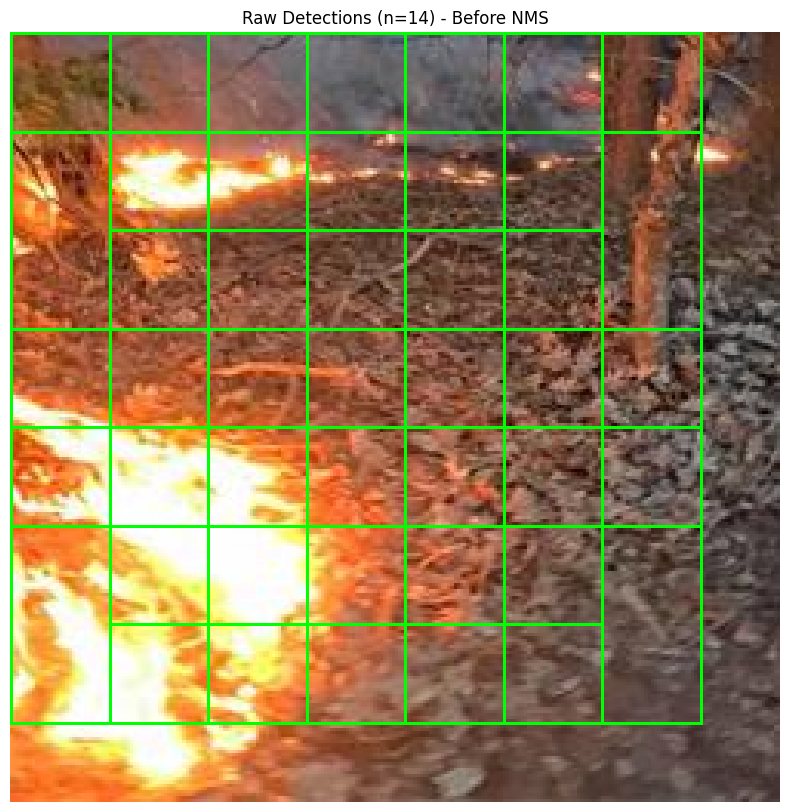


✅ Module 2.1 test PASSED!
   Next step (Module 2.2) will clean up these messy boxes.


In [15]:
"""
Module 2.1: Sliding Window Detector (CNN+SVM)
Author: CNN-SVM Project
Description: Loads the trained models (CNN & SVM) and uses them to
             perform sliding window detection on new images.
"""

# This script assumes 'Config' (Cell 1) and 'FeatureExtractor' (Cell 2)
# are in memory.

import torch
import numpy as np
import joblib
import cv2
from PIL import Image
from tqdm.notebook import tqdm
import albumentations as A
from albumentations.pytorch import ToTensorV2

# --- 1. Helper: Load All Models ---

def load_models(config):
    """
    Loads the three key components for detection:
    1. The CNN Feature Extractor
    2. The SVM Feature Scaler
    3. The trained SVM model
    """
    print("Loading models for detection...")
    
    # 1. Load CNN Extractor (from Module 1.1)
    try:
        extractor = FeatureExtractor(config)
    except NameError:
        print("ERROR: 'FeatureExtractor' class not found. Run Cell 2.")
        raise
    
    # 2. Load SVM Scaler (from Module 1.3)
    scaler_path = config.MODEL_DIR / "svm_scaler.joblib"
    try:
        scaler = joblib.load(scaler_path)
    except FileNotFoundError:
        print(f"ERROR: Scaler not found at {scaler_path}. Run Cell 4.")
        raise
        
    # 3. Load SVM Model (from Module 1.3)
    try:
        svm = joblib.load(config.SVM_MODEL_PATH)
    except FileNotFoundError:
        print(f"ERROR: SVM model not found at {config.SVM_MODEL_PATH}. Run Cell 4.")
        raise
        
    print("✅ All detection models loaded successfully.")
    return extractor, scaler, svm

# --- 2. Helper: The Sliding Window Generator ---

def sliding_window(image, window_size, step_size):
    """
    Generates (x, y, window_patch) tuples for a sliding window
    across an image.
    
    """
    img_h, img_w = image.shape[:2]
    win_h, win_w = window_size
    
    for y in range(0, img_h - win_h + 1, step_size):
        for x in range(0, img_w - win_w + 1, step_size):
            # Yield the current window's coordinates and the image patch
            yield (x, y, image[y:y+win_h, x:x+win_w])

# --- 3. The Main Detection Function ---

def detect_fire(image_path, extractor, scaler, svm, config):
    """
    Runs the full sliding window detection pipeline on a single image.
    
    Returns:
        raw_boxes (list): List of [x, y, w, h]
        confidences (list): List of confidence scores for each box
    """
    
    # 1. Load and prepare image
    image = np.array(Image.open(image_path).convert('RGB'))
    
    # Get the CNN preprocessing transform (from Module 1.1)
    transform = get_image_transform(config)
    
    raw_boxes = []
    confidences = []
    all_probs = []   # ⭐ NEW
    
    window_count = 0 # Just for a progress bar
    total_windows = ((image.shape[0] - config.WINDOW_SIZE[0]) // config.STEP_SIZE) * \
                    ((image.shape[1] - config.WINDOW_SIZE[1]) // config.STEP_SIZE)
    
    pbar = tqdm(
        sliding_window(image, config.WINDOW_SIZE, config.STEP_SIZE),
        total=total_windows,
        desc="Detecting"
    )
    
    # 2. Iterate through all sliding windows
    for (x, y, patch) in pbar:
        if patch.shape[0] != config.WINDOW_SIZE[0] or patch.shape[1] != config.WINDOW_SIZE[1]:
            continue
            
        # 3. Preprocess the patch for the CNN
        patch_tensor = transform(image=patch)['image']
        patch_batch = patch_tensor.unsqueeze(0) # (1, C, H, W)
        
        # 4. Extract features
        features = extractor.extract_features(patch_batch) # (1, 512)
        
        # 5. Scale features for SVM
        features_scaled = scaler.transform(features)
        
        # 6. Classify with SVM
        # Get probabilities: [prob_nofire, prob_fire]
        proba = svm.predict_proba(features_scaled)[0]
        fire_confidence = proba[1] # Get the confidence for "Fire" (class 1)
        all_probs.append(fire_confidence)   # ⭐ NEW (VERY IMPORTANT)
        
        # 7. Save if above threshold
        if fire_confidence > config.DETECTION_THRESHOLD:
            raw_boxes.append([x, y, config.WINDOW_SIZE[1], config.WINDOW_SIZE[0]])
            confidences.append(fire_confidence)
            
    return raw_boxes, confidences, all_probs

# ============================================
# TESTING CODE (Module 2.1)
# ============================================
# This will run when you execute the cell

print("\n🧪 Testing Module 2.1: Sliding Window Detector\n")

try:
    # 1. Check for dependencies
    if 'config' not in locals():
        print("ERROR: 'config' not found. Run Cell 1.")
        raise NameError("config")
        
    # 2. Load all models
    extractor, scaler, svm = load_models(config)
    
    # 3. Load a test image
    test_img_path = next((config.TEST_PATH / "fire").glob("*.jpg"))
    print(f"\n   Running detection on: {test_img_path}")
    
    # 4. Run detection
    # This will be slow the first time
    raw_boxes, confidences, all_probs = detect_fire(test_img_path, extractor, scaler, svm, config)
    
    print(f"\n✅ Detection complete.")
    print(f"   Found {len(raw_boxes)} raw (overlapping) boxes.")
    
    # 5. Visualize the raw, messy output
    print("   Visualizing raw detections (before NMS)...")
    
    image = np.array(Image.open(test_img_path).convert('RGB'))
    img_draw = cv2.cvtColor(image, cv2.COLOR_RGB2BGR) # to BGR
    
    for (x, y, w, h) in raw_boxes:
        cv2.rectangle(img_draw, (x, y), (x + w, y + h), (0, 255, 0), 1) # Green, thin
    
    img_draw_rgb = cv2.cvtColor(img_draw, cv2.COLOR_BGR2RGB)
    
    import matplotlib.pyplot as plt
    plt.figure(figsize=(10, 10))
    plt.imshow(img_draw_rgb)
    plt.title(f"Raw Detections (n={len(raw_boxes)}) - Before NMS")
    plt.axis('off')
    plt.show()

    print("\n✅ Module 2.1 test PASSED!")
    print("   Next step (Module 2.2) will clean up these messy boxes.")

except Exception as e:
    print(f"\n❌ Module 2.1 test FAILED: {e}")
    import traceback
    traceback.print_exc()


🧪 Testing Module 2.2: Post-Processing & NMS

Loading models for detection...
✅ FeatureExtractor ready. Hook registered on final layer.
✅ All detection models loaded successfully.

   Running detection & NMS on: Datasets\forest_fire\Testing\fire\abc169.jpg


Detecting:   0%|          | 0/9 [00:00<?, ?it/s]

   Found 14 raw boxes.
   Cleaned up to 4 final boxes after NMS.


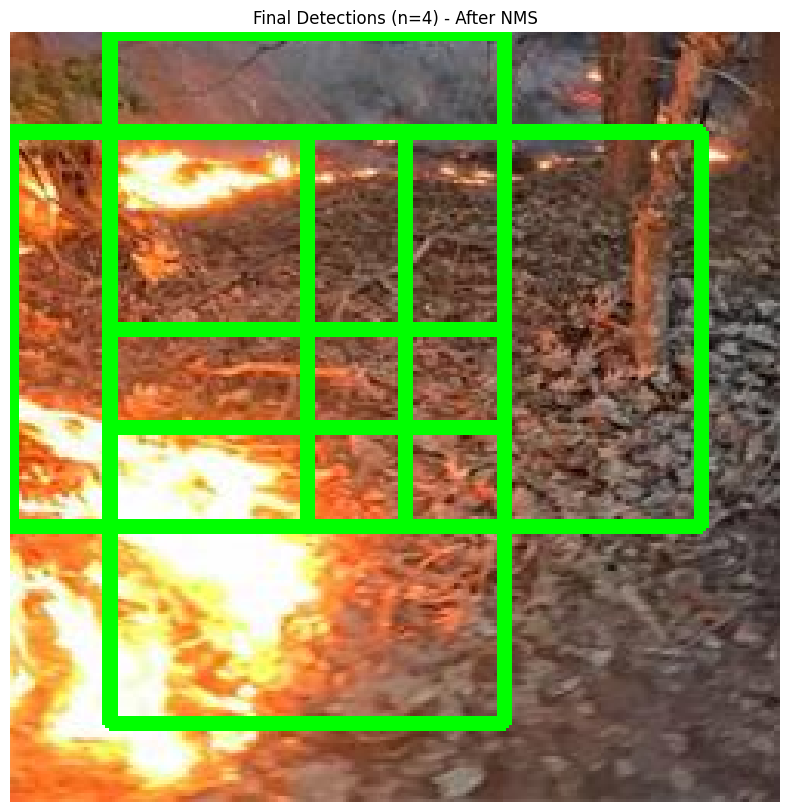


✅ Module 2.2 test PASSED!


In [17]:
"""
Module 2.2: Post-Processing & Non-Maximum Suppression (NMS) (CNN+SVM)
Author: CNN-SVM Project
Description: Cleans up the raw, overlapping detections from the sliding
             window by applying a Non-Maximum Suppression (NMS) algorithm.
"""

# This script assumes 'Config' (Cell 1), 'load_models' (Cell 5),
# and 'detect_fire' (Cell 5) are in memory.

import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image

# --- 1. The Non-Maximum Suppression (NMS) Function ---

def non_maximum_suppression(boxes, confidences, nms_threshold):
    """
    Performs Non-Maximum Suppression (NMS) on a list of boxes.
    
    Args:
        boxes (list): List of [x, y, w, h] boxes.
        confidences (list): List of confidence scores for each box.
        nms_threshold (float): The IoU (Intersection over Union) threshold.
        
    Returns:
        list: A list of the final, clean [x, y, w, h] boxes.
    """
    if not boxes:
        return []

    # Convert boxes from [x, y, w, h] to [x1, y1, x2, y2]
    # which is required by most NMS algorithms
    boxes_np = np.array(boxes)
    x1 = boxes_np[:, 0]
    y1 = boxes_np[:, 1]
    x2 = boxes_np[:, 0] + boxes_np[:, 2]
    y2 = boxes_np[:, 1] + boxes_np[:, 3]
    boxes_corners = np.stack([x1, y1, x2, y2], axis=1)
    
    confidences_np = np.array(confidences)
    
    # Get indices of boxes to keep
    # cv2.dnn.NMSBoxes returns the *indices* of the boxes
    # that were selected.
    indices = cv2.dnn.NMSBoxes(
        boxes_corners, 
        confidences_np, 
        config.DETECTION_THRESHOLD, # Redundant, but good practice
        nms_threshold
    )
    
    if len(indices) == 0:
        return []
        
    # Flatten indices if it's a nested list
    if isinstance(indices, (list, tuple)) and len(indices) > 0 and isinstance(indices[0], (list, tuple)):
        indices = indices[0]

    # Return only the boxes at the selected indices
    final_boxes = [boxes[i] for i in indices.flatten()]
    
    return final_boxes

# --- 2. The Final Visualization Function ---

def visualize_final_detections(image_path, final_boxes):
    """
    Draws the final, clean bounding boxes on an image.
    """
    image = np.array(Image.open(image_path).convert('RGB'))
    img_draw = cv2.cvtColor(image, cv2.COLOR_RGB2BGR) # to BGR
    
    for (x, y, w, h) in final_boxes:
        # Draw a bold, green box
        cv2.rectangle(img_draw, (x, y), (x + w, y + h), (0, 255, 0), 3) 
    
    img_draw_rgb = cv2.cvtColor(img_draw, cv2.COLOR_BGR2RGB)
    
    plt.figure(figsize=(10, 10))
    plt.imshow(img_draw_rgb)
    plt.title(f"Final Detections (n={len(final_boxes)}) - After NMS")
    plt.axis('off')
    plt.show()

# ============================================
# TESTING CODE (Module 2.2)
# ============================================
# This will run when you execute the cell

print("\n🧪 Testing Module 2.2: Post-Processing & NMS\n")

try:
    # 1. Check for dependencies
    if 'config' not in locals(): raise NameError("config")
    if 'load_models' not in locals(): raise NameError("load_models")
    if 'detect_fire' not in locals(): raise NameError("detect_fire")
        
    # 2. Load models
    # We re-load them to ensure this module is self-contained
    extractor, scaler, svm = load_models(config)
    
    # 3. Load a test image
    test_img_path = next((config.TEST_PATH / "fire").glob("*.jpg"))
    print(f"\n   Running detection & NMS on: {test_img_path}")
    
    # 4. Run detection (from Module 2.1)
    # This gets us the messy, raw boxes
    raw_boxes, confidences, all_probs = detect_fire(test_img_path, extractor, scaler, svm, config)
    print(f"   Found {len(raw_boxes)} raw boxes.")
    
    # 5. Run NMS (from this Module)
    # This is the key step to clean them up
    final_boxes = non_maximum_suppression(
        raw_boxes, 
        confidences, 
        config.NMS_THRESHOLD
    )
    print(f"   Cleaned up to {len(final_boxes)} final boxes after NMS.")
    
    # 6. Visualize the final, clean output
    visualize_final_detections(test_img_path, final_boxes)

    print("\n✅ Module 2.2 test PASSED!")

except Exception as e:
    print(f"\n❌ Module 2.2 test FAILED: {e}")
    import traceback
    traceback.print_exc()


🧪 Running Module 2.3: Deployment Interface

🔥 Loading and processing image: Untitled.jpg


Detecting: 0it [00:00, ?it/s]


--- 💡 FINAL DECISION 💡 ---
   Model Prediction: FIRE DETECTED
   Boxes Found: 2


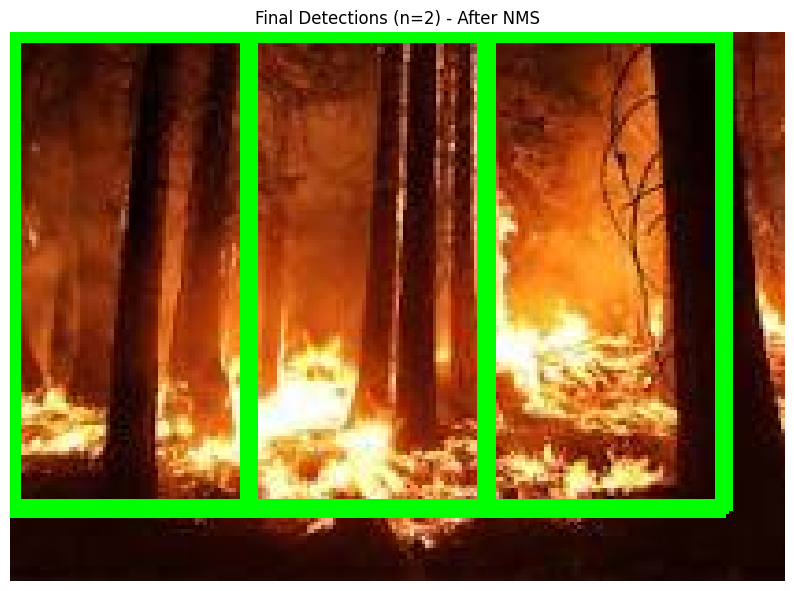


✅ Module 2.3 test complete.


In [19]:
"""
Module 2.3: Deployment Interface (CNN+SVM)
Author: CNN-SVM Project
Description: A simple interface to run the full detection pipeline
             on any single image provided by the user.
"""

# This script assumes 'Config' (Cell 1), 'load_models' (Cell 5),
# 'detect_fire' (Cell 5), and 'visualize_final_detections' (Cell 6)
# are all in memory.

import os
import matplotlib.pyplot as plt

print("\n🧪 Running Module 2.3: Deployment Interface\n")

# =================================================================
# --- 1. SET YOUR IMAGE PATH HERE ---
#
# ⬇️ ⬇️ ⬇️
# Change this to the full path of any image you want to test
# e.g., r"C:\Users\Sreeh\Desktop\my_test_fire_image.jpg"
#
YOUR_IMAGE_PATH = "Untitled.jpg"
# ⬆️ ⬆️ ⬆️
#
# =================================================================


try:
    # --- 2. Check that everything is ready ---
    
    # Check if models are loaded
    if 'extractor' not in locals() or 'scaler' not in locals() or 'svm' not in locals():
        print("   Models not loaded. Loading them now...")
        extractor, scaler, svm = load_models(config)
        
    # Check if the path was changed
    if YOUR_IMAGE_PATH == "path/to/your/image.jpg":
        print("❌ ERROR: Please set the 'YOUR_IMAGE_PATH' variable")
        print("   in this cell to the path of an image you want to test.")
        raise ValueError("Image path not set")
        
    # Check if the file exists
    if not os.path.exists(YOUR_IMAGE_PATH):
        print(f"❌ ERROR: File not found at: {YOUR_IMAGE_PATH}")
        raise FileNotFoundError("Image file does not exist")

    # --- 3. Run the Full Pipeline ---
    print(f"🔥 Loading and processing image: {YOUR_IMAGE_PATH}")
    
    # Step 1: Run sliding window (from Module 2.1)
    raw_boxes, confidences, all_probs = detect_fire(YOUR_IMAGE_PATH, extractor, scaler, svm, config)
    
    # Step 2: Run NMS (from Module 2.2)
    final_boxes = non_maximum_suppression(
        raw_boxes, confidences, config.NMS_THRESHOLD
    )
    
    print(f"\n--- 💡 FINAL DECISION 💡 ---")
    if final_boxes:
        print(f"   Model Prediction: FIRE DETECTED")
        print(f"   Boxes Found: {len(final_boxes)}")
    else:
        print(f"   Model Prediction: No Fire Detected")
    
    # --- 4. Show the Final Result ---
    # (function from Module 2.2)
    visualize_final_detections(YOUR_IMAGE_PATH, final_boxes)

    print("\n✅ Module 2.3 test complete.")

except Exception as e:
    print(f"\n❌ Module 2.3 test FAILED: {e}")
    import traceback
    traceback.print_exc()


🧪 Running FINAL Module 3.1

Loading models for evaluation...
Loading models for detection...
✅ FeatureExtractor ready. Hook registered on final layer.
✅ All detection models loaded successfully.
Found 68 total test images.


Evaluating:   0%|          | 0/68 [00:00<?, ?it/s]

Detecting:   0%|          | 0/9 [00:00<?, ?it/s]

Detecting:   0%|          | 0/9 [00:00<?, ?it/s]

Detecting:   0%|          | 0/9 [00:00<?, ?it/s]

...

Detecting:   0%|          | 0/9 [00:00<?, ?it/s]

Detecting:   0%|          | 0/9 [00:00<?, ?it/s]

Detecting:   0%|          | 0/9 [00:00<?, ?it/s]

Detecting:   0%|          | 0/9 [00:00<?, ?it/s]


--- Classification Report ---
              precision    recall  f1-score   support

      NoFire       1.00      0.91      0.95        46
        Fire       0.85      1.00      0.92        22

    accuracy                           0.94        68
   macro avg       0.92      0.96      0.94        68
weighted avg       0.95      0.94      0.94        68



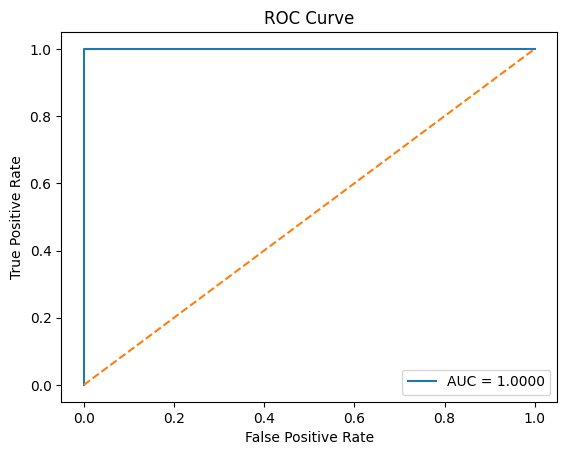

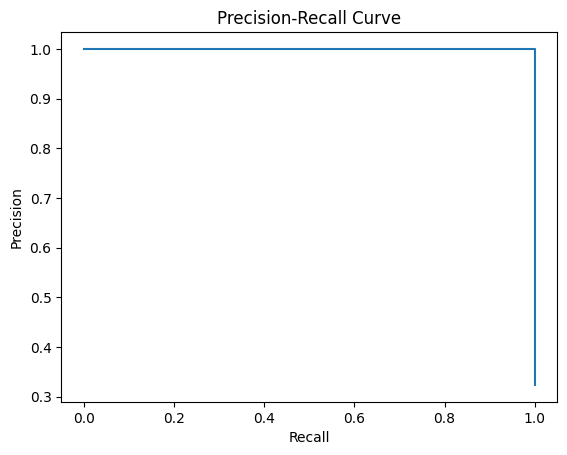

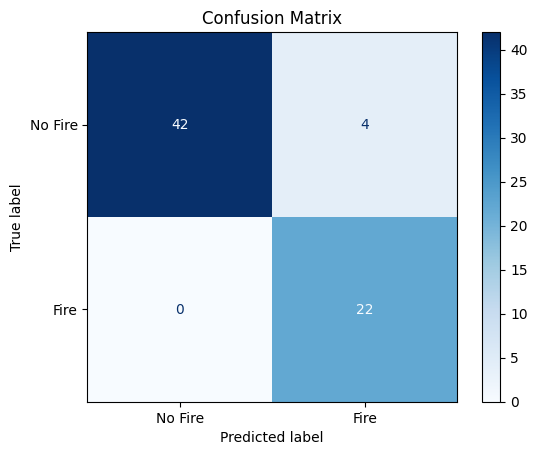


DEBUG INFO:
Unique scores: [np.float64(0.0), np.float64(0.001), np.float64(0.002), np.float64(0.003), np.float64(0.006), np.float64(0.007), np.float64(0.008), np.float64(0.009), np.float64(0.01), np.float64(0.012), np.float64(0.013), np.float64(0.015), np.float64(0.016), np.float64(0.022), np.float64(0.037), np.float64(0.041), np.float64(0.047), np.float64(0.054), np.float64(0.066), np.float64(0.085), np.float64(0.121), np.float64(0.127), np.float64(0.188), np.float64(0.208), np.float64(0.313), np.float64(0.339), np.float64(0.709), np.float64(0.783), np.float64(0.823), np.float64(0.833), np.float64(0.835), np.float64(0.846), np.float64(0.85), np.float64(0.858), np.float64(0.871), np.float64(0.873), np.float64(0.9), np.float64(0.919), np.float64(0.978), np.float64(0.982), np.float64(0.989), np.float64(0.994), np.float64(0.995), np.float64(0.997), np.float64(0.998), np.float64(1.0)]
Min: 2.8541014479068396e-06 Max: 0.9997399522033381

✅ Evaluation complete!


In [20]:
"""
Module 3.1: Evaluation Metrics Calculator (FINAL FIXED)
"""

import torch
import numpy as np
import matplotlib.pyplot as plt
import itertools
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_curve, auc, precision_recall_curve, ConfusionMatrixDisplay
from tqdm.notebook import tqdm

# --- Confusion Matrix Function ---
def plot_confusion_matrix(y_true, y_pred):
    disp = ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred,
        display_labels=["No Fire", "Fire"],
        cmap='Blues'
    )
    plt.title("Confusion Matrix")
    plt.show()


# --- Evaluation Function ---
def evaluate_pipeline(config):

    print("Loading models for evaluation...")
    extractor, scaler, svm = load_models(config)

    fire_test_paths = list((config.TEST_PATH / "fire").glob("*.jpg"))
    nofire_test_paths = list((config.TEST_PATH / "nofire").glob("*.jpg"))

    all_test_paths = [str(p) for p in (fire_test_paths + nofire_test_paths)]
    all_true_labels = [1] * len(fire_test_paths) + [0] * len(nofire_test_paths)

    print(f"Found {len(all_test_paths)} total test images.")

    y_true = []
    y_pred = []
    y_scores = []

    pbar = tqdm(zip(all_test_paths, all_true_labels),
                total=len(all_test_paths),
                desc="Evaluating")

    for image_path, true_label in pbar:

        # 🔥 MODIFIED detect_fire → MUST return all_probs
        raw_boxes, confidences, all_probs = detect_fire(
            image_path, extractor, scaler, svm, config
        )

        # --- Prediction ---
        pred_label = 1 if len(raw_boxes) > 0 else 0

        # --- SCORE (CRITICAL FIX) ---
        if len(all_probs) > 0:
            prob = np.mean(all_probs)

            # 🔥 Smooth extreme probabilities
            prob = np.clip(prob, 1e-6, 1 - 1e-6)
        else:
            prob = 0

        y_true.append(true_label)
        y_pred.append(pred_label)
        y_scores.append(prob)

    # =============================
    # 📊 CLASSIFICATION REPORT
    # =============================
    print("\n--- Classification Report ---")
    print(classification_report(
        y_true, y_pred,
        target_names=["NoFire", "Fire"],
        zero_division=0
    ))

    # =============================
    # 🔥 ROC CURVE
    # =============================
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0, 1], [0, 1], linestyle='--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()

    # =============================
    # 🔥 PRECISION-RECALL CURVE
    # =============================
    precision, recall, _ = precision_recall_curve(y_true, y_scores)

    plt.figure()
    plt.plot(recall, precision)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curve")
    plt.show()

    # =============================
    # 🔥 CONFUSION MATRIX
    # =============================
    plot_confusion_matrix(y_true, y_pred)

    # =============================
    # 🔍 DEBUG (OPTIONAL)
    # =============================
    print("\nDEBUG INFO:")
    print("Unique scores:", sorted(set(np.round(y_scores, 3))))
    print("Min:", min(y_scores), "Max:", max(y_scores))

    return y_true, y_pred


# =============================
# RUN
# =============================
print("\n🧪 Running FINAL Module 3.1\n")

try:
    y_true, y_pred = evaluate_pipeline(config)
    print("\n✅ Evaluation complete!")

except Exception as e:
    print(f"\n❌ FAILED: {e}")
    import traceback
    traceback.print_exc()